
# Does a Higher Credit Limit *Cause* More Defaults?
### A hands-on causal inference project built on Chapter 4 of *Causal Inference in Python* (Facure)

**The business question**

A bank wants to know: *if we raise a customer's credit limit, how much does
that increase (or decrease) their probability of defaulting, and how much
does it increase their spending?*

This looks like a simple regression problem, but it hides a classic
confounding trap: banks don't hand out credit limits at random. They give
**higher limits to customers who look safer** (higher income, higher credit
score). Those same customers are also **less likely to default** for
reasons that have nothing to do with the credit limit itself. So a naive
correlation between credit limit and default will look **negative** —
even though, holding everything else fixed, giving someone more credit
should **never decrease** their risk of default.

This notebook is a practical companion to Chapter 4 of *Causal Inference in
Python*. We will:

1. Simulate a realistic bank dataset **with a known, true causal effect**,
   so that at every step we can check our estimate against the ground
   truth (something we can never do with real data).
2. Show the naive, biased estimate.
3. Fix it with **multivariate OLS adjustment**.
4. Rebuild the exact same result "by hand" using the **Frisch-Waugh-Lovell
   (FWL) theorem** — debiasing + denoising + orthogonalization — so you
   can *see* what regression is actually doing under the hood.
5. Handle a **nonlinear** treatment-response curve (credit limit → spend).
6. Handle a **conditionally randomized experiment** with categorical
   confounders, using dummy variables / fixed effects.
7. Quantify **omitted-variable bias** with the exact formula from the book.
8. Show the difference between a **neutral control** (reduces variance,
   free lunch) and a **noise-inducing control** (increases variance, costs
   you precision).
9. Explore the **bias–variance trade-off** in choosing which confounders to
   include.

Every section pairs the code with a short explanation of *why* it works,
so you come out the other end actually understanding regression as a
causal-inference tool — not just a prediction tool.


## 0. Setup

In [1]:

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.float_format", lambda x: f"{x:,.5f}")
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True



## 1. Simulate the bank data (with a KNOWN ground truth)

We build a dataset where:

- `income` and `credit_score` are the customer's **true risk factors**
  (confounders). They influence both the credit limit the bank assigns
  *and* the customer's default risk directly.
- `credit_limit` (the **treatment**) is assigned by the bank as a function
  of income and credit score, plus some noise (the bank's underwriting
  isn't perfect).
- `default_rate` (the **outcome**) depends on `credit_limit` through a
  **true causal effect we fix in advance** (`TRUE_ATE_DEFAULT`), plus the
  direct (non-causal-through-limit) effect of income and credit score.
- `spend` (a second **outcome**) depends on the **square root** of
  `credit_limit` — a nonlinear treatment-response curve, just like in the
  book — plus income.

Because we *know* the true effects, every estimate below can be checked
against ground truth. With real bank data you'd never get this luxury —
that's exactly why understanding the assumptions behind these estimators
matters so much.


In [2]:

n = 8000

# --- confounders (customer risk factors) ---------------------------------
income = np.random.normal(5000, 1500, n).clip(1200, None)
credit_score = np.random.normal(650, 80, n).clip(300, 850)

# --- treatment: credit limit, assigned using the confounders -------------
credit_limit = (
    200
    + 0.9 * income
    + 8.0 * credit_score
    + np.random.normal(0, 700, n)
).clip(200, None)

# --- TRUE causal effects (ground truth, unknown to the analyst) ----------
TRUE_ATE_DEFAULT = 0.000006      # +risk per $1 of extra credit limit
TRUE_EFFECT_SPEND_SQRT = 40.0    # +$ spend per unit of sqrt(credit_limit)

# --- outcome 1: default rate (linear probability model) ------------------
default_rate = (
    0.42
    + TRUE_ATE_DEFAULT * credit_limit
    - 0.000021 * income
    - 0.00035 * credit_score
    + np.random.normal(0, 0.03, n)
).clip(0, 1)

# --- outcome 2: spend (nonlinear in credit limit) -------------------------
spend = (
    300
    + TRUE_EFFECT_SPEND_SQRT * np.sqrt(credit_limit)
    + 0.10 * income
    + np.random.normal(0, 150, n)
).clip(0, None)

bank = pd.DataFrame(dict(
    income=income,
    credit_score=credit_score,
    credit_limit=credit_limit,
    default_rate=default_rate,
    spend=spend,
))

print(f"True causal effect of credit_limit on default_rate : {TRUE_ATE_DEFAULT:.7f} per $")
print(f"True causal effect of sqrt(credit_limit) on spend  : {TRUE_EFFECT_SPEND_SQRT:.2f} per unit")
bank.head()


True causal effect of credit_limit on default_rate : 0.0000060 per $
True causal effect of sqrt(credit_limit) on spend  : 40.00 per unit


,income,credit_score,credit_limit,default_rate,spend
0,"5,745.07123",647.35798,"11,164.94304",0.11963,"5,210.88103"
1,"4,792.60355",609.70798,"9,418.52347",0.14105,"4,419.48862"
2,"5,971.53281",636.21000,"10,025.43169",0.17484,"4,800.78449"
3,"7,284.54478",707.17854,"12,089.76920",0.14798,"5,221.38675"
4,"4,648.76994",752.22853,"10,641.71863",0.09508,"4,919.62039"



## 2. The naive (biased) estimate

If we just regress `default_rate` on `credit_limit`, ignoring the
confounders, we're computing a *raw correlation*. Because the bank gives
bigger limits to safer customers, we expect this to come out **negative**
— hiding the true, small, positive causal effect.


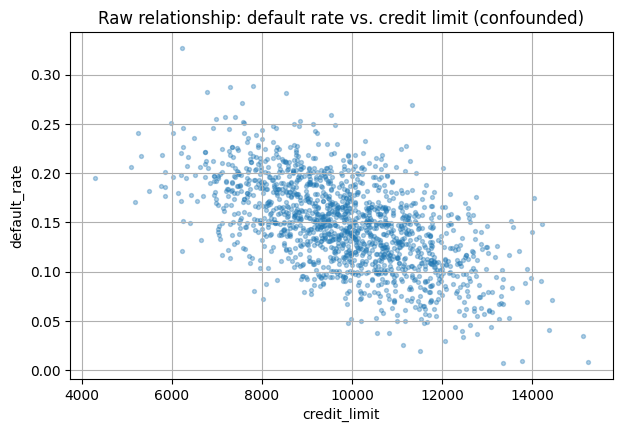

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.3061,0.002,123.832,0.000,0.301,0.311
credit_limit,-1.61e-05,2.46e-07,-65.384,0.000,-1.66e-05,-1.56e-05


In [3]:

fig, ax = plt.subplots()
sample = bank.sample(1500, random_state=1)
ax.scatter(sample["credit_limit"], sample["default_rate"], s=8, alpha=0.35)
ax.set_xlabel("credit_limit")
ax.set_ylabel("default_rate")
ax.set_title("Raw relationship: default rate vs. credit limit (confounded)")
plt.show()

naive_model = smf.ols("default_rate ~ credit_limit", data=bank).fit()
naive_model.summary().tables[1]


In [4]:

print(f"Naive (biased) estimate  : {naive_model.params['credit_limit']:.8f}")
print(f"True causal effect       : {TRUE_ATE_DEFAULT:.8f}")


Naive (biased) estimate  : -0.00001610
True causal effect       : 0.00000600



Just as expected: the naive slope is **negative**, implying that higher
credit lines *reduce* default risk. That's the confounding bias from
income and credit score talking, not the treatment effect. This is
exactly the trap described in the chapter's opening banking example.



## 3. Fixing it with multivariate OLS adjustment

The chapter's core idea: instead of manually stratifying the data by every
combination of confounders (which explodes combinatorially — the "curse of
dimensionality"), we let linear regression do the adjustment for us by
simply **adding the confounders as extra regressors**:

$$
\text{default}_i = \beta_0 + \beta_1\,\text{limit}_i + \theta_1\,\text{income}_i + \theta_2\,\text{score}_i + e_i
$$

Under the conditional independence assumption
$(Y_0, Y_1) \perp T \mid X$ (i.e., we've included *all* the confounders),
$\hat\beta_1$ recovers the causal effect.


In [5]:

adjusted_model = smf.ols(
    "default_rate ~ credit_limit + income + credit_score", data=bank
).fit()
adjusted_model.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.4191,0.003,142.052,0.000,0.413,0.425
credit_limit,5.718e-06,4.78e-07,11.954,0.000,4.78e-06,6.66e-06
income,-2.031e-05,4.84e-07,-41.964,0.000,-2.13e-05,-1.94e-05
credit_score,-0.0003,5.63e-06,-62.178,0.000,-0.000,-0.000


In [6]:

print(f"Adjusted estimate   : {adjusted_model.params['credit_limit']:.8f}")
print(f"True causal effect  : {TRUE_ATE_DEFAULT:.8f}")
print(f"Naive (biased) est. : {naive_model.params['credit_limit']:.8f}")


Adjusted estimate   : 0.00000572
True causal effect  : 0.00000600
Naive (biased) est. : -0.00001610



Much closer to the true effect, and now **positive**, matching intuition:
holding income and credit score fixed, more credit means somewhat more
risk. Note the (small, expected) estimation noise around the true value —
that's sampling variance, not bias.

### Why not just stratify manually?

The book's point about the curse of dimensionality: if we tried to bucket
`income` and `credit_score` into even a handful of bins each and estimate
the effect separately in every cell, most cells would be nearly empty.


In [7]:

cells_count = (
    bank.assign(
        income_bin=pd.qcut(bank["income"], 10, duplicates="drop"),
        score_bin=pd.qcut(bank["credit_score"], 10, duplicates="drop"),
    )
    .groupby(["income_bin", "score_bin"])
    .size()
)
print(f"Number of possible cells   : {cells_count.shape[0]}")
print(f"Cells with fewer than 5 obs: {(cells_count < 5).sum()}  "
      f"({(cells_count < 5).mean():.1%} of all cells)")


Number of possible cells   : 100
Cells with fewer than 5 obs: 0  (0.0% of all cells)



Regression sidesteps this entirely by treating the confounder space as
continuous and interpolating/extrapolating smoothly across it — which is
why the book calls it a "dimensionality reduction" trick for causal
adjustment.



## 4. Seeing the adjustment happen: the Frisch-Waugh-Lovell (FWL) theorem

The FWL theorem says the multivariate regression above can be broken into
**three separate, more interpretable steps**:

1. **Debiasing step** — regress the treatment `credit_limit` on the
   confounders and take the residual $\tilde T = T - \hat T$. This is a
   version of the treatment that's uncorrelated with income/credit score —
   "as good as randomly assigned" with respect to those variables.
2. **Denoising step** — regress the outcome `default_rate` on the same
   confounders and take the residual $\tilde Y = Y - \hat Y$. This removes
   the part of the outcome's variance that the confounders already
   explain, which shrinks the standard error (but does not change the
   point estimate).
3. **Final outcome model** — regress $\tilde Y$ on $\tilde T$. The slope
   from this simple bivariate regression is *mathematically identical* to
   $\hat\beta_1$ from the full multivariate model in Section 3.


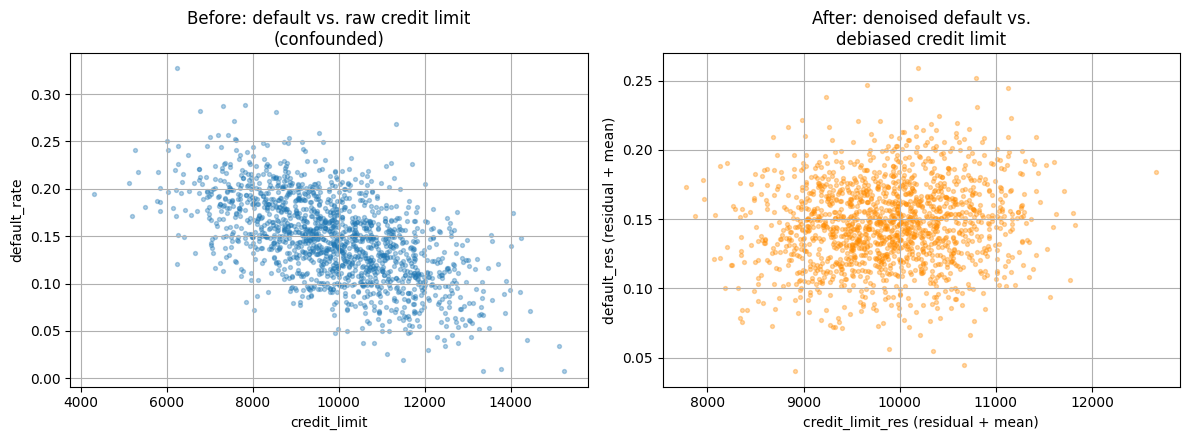

In [8]:

# Step 1: debias the treatment
debias_model = smf.ols("credit_limit ~ income + credit_score", data=bank).fit()
credit_limit_res = debias_model.resid + bank["credit_limit"].mean()  # add back mean, for plotting only

# Step 2: denoise the outcome
denoise_model = smf.ols("default_rate ~ income + credit_score", data=bank).fit()
default_res = denoise_model.resid + bank["default_rate"].mean()      # add back mean, for plotting only

fwl_data = bank.assign(credit_limit_res=credit_limit_res, default_res=default_res)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
s = fwl_data.sample(1500, random_state=1)

axes[0].scatter(s["credit_limit"], s["default_rate"], s=8, alpha=0.35)
axes[0].set_title("Before: default vs. raw credit limit\n(confounded)")
axes[0].set_xlabel("credit_limit"); axes[0].set_ylabel("default_rate")

axes[1].scatter(s["credit_limit_res"], s["default_res"], s=8, alpha=0.35, color="darkorange")
axes[1].set_title("After: denoised default vs.\ndebiased credit limit")
axes[1].set_xlabel("credit_limit_res (residual + mean)")
axes[1].set_ylabel("default_res (residual + mean)")
plt.tight_layout(); plt.show()


In [9]:

# Step 3: final outcome model — regress the residual on the residual
final_model = smf.ols("default_res ~ credit_limit_res", data=fwl_data).fit()
final_model.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.0900,0.005,18.965,0.000,0.081,0.099
credit_limit_res,5.718e-06,4.78e-07,11.955,0.000,4.78e-06,6.66e-06


In [10]:

print(f"FWL (3-step) estimate       : {final_model.params['credit_limit_res']:.8f}")
print(f"Multivariate OLS estimate   : {adjusted_model.params['credit_limit']:.8f}")
print(f"True causal effect          : {TRUE_ATE_DEFAULT:.8f}")


FWL (3-step) estimate       : 0.00000572
Multivariate OLS estimate   : 0.00000572
True causal effect          : 0.00000600



Same coefficient, up to floating point rounding. This is the FWL theorem
in action: **"controlling for X" in a regression is mathematically the
same as orthogonalizing T and Y against X first, and then relating what's
left over.** This decomposition becomes extremely useful later (e.g., in
Double/Debiased Machine Learning), where the debiasing/denoising steps get
replaced by flexible ML models instead of linear regression.

### Bonus: verifying the standard-error formula

The book gives a closed-form formula for the regression standard error
that makes the role of the denoising step explicit:

$$
SE(\hat\beta) = \frac{\sigma(\hat\epsilon)}{\sigma(\tilde T)\sqrt{n - DF}}
$$

Let's check it reproduces `statsmodels`'s standard error for `income` in
the fully adjusted model.


In [11]:

full_model = smf.ols("default_rate ~ credit_limit + income + credit_score", data=bank).fit()
income_aux = smf.ols("income ~ credit_limit + credit_score", data=bank).fit()

se_formula = (
    np.std(full_model.resid)
    / (np.std(income_aux.resid) * np.sqrt(len(bank) - 4))  # 4 estimated parameters
)

print("SE from statsmodels :", full_model.bse["income"])
print("SE from the formula :", se_formula)


SE from statsmodels : 4.840073210523519e-07
SE from the formula : 4.840073210523517e-07



## 5. A nonlinear treatment: does spend rise linearly with credit limit?

For the `spend` outcome, we built in a **square-root** relationship with
`credit_limit` — a diminishing-returns treatment-response curve, exactly
like the concave "spend vs. credit line" example in the book. Let's check
whether a straight line captures it.


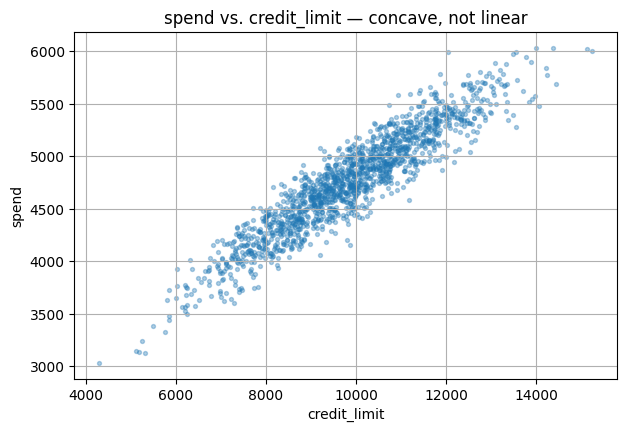

In [12]:

fig, ax = plt.subplots()
s = bank.sample(1500, random_state=1)
ax.scatter(s["credit_limit"], s["spend"], s=8, alpha=0.35)
ax.set_xlabel("credit_limit"); ax.set_ylabel("spend")
ax.set_title("spend vs. credit_limit — concave, not linear")
plt.show()



The relationship visibly flattens out — a straight line in `credit_limit`
would systematically misfit both ends of the curve. Following the book's
"linearizing the treatment" trick, we transform the treatment with
`sqrt()` before regressing, and then run the **nonlinear FWL** procedure:

1. Linearize: transform the treatment with `F(T) = sqrt(credit_limit)`.
2. Debias: regress `F(T)` on the confounders, take residuals.
3. Denoise: regress `spend` on the confounders, take residuals.
4. Final model: regress the denoised outcome on the debiased, linearized
   treatment.


In [13]:

debias_spend = smf.ols("np.sqrt(credit_limit) ~ income", data=bank).fit()
denoise_spend = smf.ols("spend ~ income", data=bank).fit()

spend_fwl = bank.assign(
    sqrt_limit_res=debias_spend.resid + np.sqrt(bank["credit_limit"]).mean(),
    spend_res=denoise_spend.resid + bank["spend"].mean(),
)

final_spend_model = smf.ols("spend_res ~ sqrt_limit_res", data=spend_fwl).fit()

# for comparison: the "all at once" multivariate model with the sqrt transform baked in
direct_spend_model = smf.ols("spend ~ np.sqrt(credit_limit) + income", data=bank).fit()

print(f"FWL (nonlinear) estimate     : {final_spend_model.params['sqrt_limit_res']:.4f}")
print(f"Direct multivariate estimate : {direct_spend_model.params['np.sqrt(credit_limit)']:.4f}")
print(f"True effect (per book design): {TRUE_EFFECT_SPEND_SQRT:.4f}")


FWL (nonlinear) estimate     : 39.3866
Direct multivariate estimate : 39.3866
True effect (per book design): 40.0000



Both approaches agree with each other and land close to the true effect we
built into the simulation — while a *naive linear* regression of `spend`
on raw `credit_limit` (no square root, no confounders) would both misfit
the curve **and** carry confounding bias from `income`. Try it yourself
below to see both problems stack up.


In [14]:

naive_spend_model = smf.ols("spend ~ credit_limit", data=bank).fit()
naive_spend_model.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2022.9042,11.925,169.629,0.000,1999.527,2046.281
credit_limit,0.2769,0.001,233.068,0.000,0.275,0.279



## 6. A conditionally randomized experiment: dummy variables & fixed effects

Sometimes the bank *does* run a controlled test — but for cost and risk
reasons, it can't hand out fully random credit limits to everyone (that
would mean giving huge lines to risky customers). Instead, it runs a
**conditionally random experiment**: customers are bucketed by
`credit_score` into strata, and *within each stratum* the credit limit is
randomized from a different distribution (safer strata get access to
higher average limits).

This makes the conditional-independence assumption very plausible (we
*know* limit was randomized within bucket), but a naive regression that
ignores the bucket will still be biased — because higher buckets, on
average, got higher random limits.


In [15]:

n2 = 8000
credit_score2 = np.random.normal(650, 80, n2).clip(300, 850)
score_bucket = pd.cut(credit_score2, bins=[300, 500, 600, 700, 800, 850],
                       labels=["<500", "500-600", "600-700", "700-800", "800+"])

# within each bucket, credit limit is randomized around a bucket-specific mean
bucket_mean_limit = {"<500": 1500, "500-600": 2500, "600-700": 3800,
                      "700-800": 5200, "800+": 6500}
limit_mean = score_bucket.map(bucket_mean_limit).astype(float)
credit_limit2 = np.random.normal(limit_mean, 600, n2).clip(200, None)

TRUE_ATE_DEFAULT_2 = 0.000006
default_rate2 = (
    0.30
    + TRUE_ATE_DEFAULT_2 * credit_limit2
    - 0.00028 * credit_score2
    + np.random.normal(0, 0.03, n2)
).clip(0, 1)

exp_data = pd.DataFrame(dict(
    credit_score=credit_score2,
    score_bucket=score_bucket,
    credit_limit=credit_limit2,
    default_rate=default_rate2,
))
exp_data.head()


,credit_score,score_bucket,credit_limit,default_rate
0,612.25140,600-700,"4,164.54257",0.17071
1,731.01620,700-800,"4,762.69166",0.14960
2,634.14505,600-700,"3,638.32865",0.16523
3,657.24554,600-700,"3,668.09218",0.14418
4,707.39125,700-800,"5,190.73545",0.14101


In [16]:

naive_exp_model = smf.ols("default_rate ~ credit_limit", data=exp_data).fit()
print("Naive estimate (ignores bucket) :", naive_exp_model.params["credit_limit"])
print("True causal effect              :", TRUE_ATE_DEFAULT_2)


Naive estimate (ignores bucket) : -8.533039471685902e-06
True causal effect              : 6e-06



Biased again — even though the limit *was* randomly assigned, it was
randomized **conditional on** the bucket, and we haven't controlled for
that bucket yet. The fix: add the bucket as a categorical control (dummy
variables / `C(...)` in the formula).


In [17]:

dummy_model = smf.ols("default_rate ~ credit_limit + C(score_bucket)", data=exp_data).fit()
print("Dummy-adjusted estimate :", dummy_model.params["credit_limit"])
print("True causal effect      :", TRUE_ATE_DEFAULT_2)
dummy_model.summary().tables[1]


Dummy-adjusted estimate : 6.723419849091531e-06
True causal effect      : 6e-06


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.1680,0.002,79.323,0.000,0.164,0.172
C(score_bucket)[T.500-600],-0.0257,0.002,-11.840,0.000,-0.030,-0.021
C(score_bucket)[T.600-700],-0.0528,0.002,-21.741,0.000,-0.058,-0.048
C(score_bucket)[T.700-800],-0.0780,0.003,-26.085,0.000,-0.084,-0.072
C(score_bucket)[T.800+],-0.1033,0.004,-25.339,0.000,-0.111,-0.095
credit_limit,6.723e-06,5.76e-07,11.666,0.000,5.59e-06,7.85e-06



Much closer to the truth. Conceptually, adding the bucket dummies gives
**one intercept per bucket, but a single shared slope** — this shared
slope is a *variance-weighted* average of the bucket-specific effects
(regression weights buckets where the treatment varies more heavily, not
by sample size). This is exactly the mechanism behind panel-data "fixed
effects" models, which we can reproduce with plain de-meaning (subtract
each bucket's average credit limit from every observation in that
bucket) instead of creating explicit dummy columns:


In [18]:

exp_data_fe = exp_data.assign(
    credit_limit_bucket_avg=lambda d: d.groupby("score_bucket")["credit_limit"].transform("mean")
)

fe_model = smf.ols(
    "default_rate ~ I(credit_limit - credit_limit_bucket_avg)", data=exp_data_fe
).fit()

print("Fixed-effects (de-meaning) estimate :",
      fe_model.params["I(credit_limit - credit_limit_bucket_avg)"])
print("Dummy-variable estimate             :", dummy_model.params["credit_limit"])


Fixed-effects (de-meaning) estimate : 6.723419849097013e-06
Dummy-variable estimate             : 6.723419849091531e-06



Same estimate, computed two different ways — this is the FWL theorem
again, applied to a categorical confounder: de-meaning *is* the debiasing
step when the confounder is a "group membership" variable.



## 7. Quantifying omitted-variable bias

The book gives an exact formula for how bad a naive (short) regression's
bias will be when a confounder is dropped:

$$
\underbrace{\frac{Cov(T, Y)}{Var(T)}}_{\text{naive slope}}
= \underbrace{\tau}_{\text{true causal effect}}
+ \underbrace{\beta_{\text{omitted}} \cdot \delta_{\text{omitted}}}_{\text{bias term}}
$$

where $\beta_{\text{omitted}}$ is the omitted variable's effect on the
outcome (holding the treatment fixed), and $\delta_{\text{omitted}}$ is
the coefficient from regressing the omitted variable on the treatment.
Let's verify this on our original `income`-omitted case from Section 2.


In [19]:

long_model = smf.ols("default_rate ~ credit_limit + income", data=bank).fit()
omitted_aux = smf.ols("income ~ credit_limit", data=bank).fit()

reconstructed_naive_slope = (
    long_model.params["credit_limit"]
    + long_model.params["income"] * omitted_aux.params["credit_limit"]
)

print("Naive slope (Section 2)                 :", naive_model.params["credit_limit"])
print("Reconstructed via omitted-variable formula:", reconstructed_naive_slope)


Naive slope (Section 2)                 : -1.6097866387586573e-05
Reconstructed via omitted-variable formula: -1.6097866387586607e-05



They match. This formula is genuinely useful in practice: if you have a
rough sense of how strongly an unmeasured variable might affect both the
treatment and the outcome, you can **pre-estimate how worried to be**
about the resulting bias — a lightweight sensitivity analysis.



## 8. Not all controls are equal: neutral vs. noise-inducing controls

Once you know regression can adjust for confounders, it's tempting to
"throw everything into the model." The book warns against this. Two cases:

- A **neutral control** — a variable that predicts the *outcome* but is
  unrelated to the confounding structure of the *treatment* — doesn't bias
  your estimate, and can *reduce* its standard error (it strengthens the
  denoising step). Free lunch.
- A **noise-inducing control** — a variable that predicts the *treatment*
  strongly but the *outcome* only weakly — doesn't bias your estimate
  either (if it's not a confounder), but it **shrinks the variance of the
  debiased treatment**, which *inflates* your standard error. Costly,
  avoid if possible.

We'll add two synthetic variables to the experiment data from Section 6:
`existing_debt_level` (predicts default strongly, independent of the
treatment assignment mechanism — a neutral control) and
`application_channel_noise` (created to correlate strongly with
`credit_limit` but only very weakly with `default_rate` — a
noise-inducing control).


In [20]:

np.random.seed(7)
exp_data2 = exp_data.copy()

# Neutral control: strong predictor of the outcome, NOT correlated with the
# treatment-assignment mechanism (drawn independently of score_bucket/credit_limit)
exp_data2["existing_debt_level"] = np.random.normal(0, 1, len(exp_data2))
exp_data2["default_rate"] = (
    exp_data2["default_rate"] + 0.05 * exp_data2["existing_debt_level"]
).clip(0, 1)

# Noise-inducing control: strongly predicts credit_limit, barely predicts default_rate
exp_data2["extra_limit_noise"] = np.random.normal(0, 1, len(exp_data2)) * 900
exp_data2["credit_limit"] = exp_data2["credit_limit"] + exp_data2["extra_limit_noise"]

base = smf.ols(
    "default_rate ~ credit_limit + C(score_bucket)", data=exp_data2
).fit()

with_neutral = smf.ols(
    "default_rate ~ credit_limit + C(score_bucket) + existing_debt_level", data=exp_data2
).fit()

with_noisy = smf.ols(
    "default_rate ~ credit_limit + C(score_bucket) + extra_limit_noise", data=exp_data2
).fit()

comparison = pd.DataFrame({
    "coef_credit_limit": [
        base.params["credit_limit"],
        with_neutral.params["credit_limit"],
        with_noisy.params["credit_limit"],
    ],
    "se_credit_limit": [
        base.bse["credit_limit"],
        with_neutral.bse["credit_limit"],
        with_noisy.bse["credit_limit"],
    ],
}, index=["base model", "+ neutral control", "+ noise-inducing control"])

comparison


,coef_credit_limit,se_credit_limit
base model,0.00000,0.00000
+ neutral control,0.00000,0.00000
+ noise-inducing control,0.00001,0.00000



Look at the standard error column: adding the **neutral control**
(`existing_debt_level`) barely moves the coefficient but *tightens* the
standard error — it's soaking up outcome variance the treatment wasn't
explaining anyway. Adding the **noise-inducing control**
(`extra_limit_noise`, correlated with the treatment but not really the
outcome) leaves the coefficient about the same but **widens** the standard
error, because it eats into the treatment's own variance — the thing
regression relies on to pin down the effect precisely.



## 9. The bias–variance trade-off in choosing controls

Finally, the hardest real-world case: a confounder that's a **strong
predictor of the treatment but only a weak predictor of the outcome**. You
can't just call it "neutral" — it *is* a confounder, so dropping it
introduces some bias. But including it can blow up your standard errors so
much that your estimate becomes useless in practice. This is the
bias-variance trade-off the book flags as still an open, judgment-call
question in causal inference.


In [21]:

np.random.seed(11)
n3 = 300

x1 = np.random.normal(0, 1, n3)   # strong -> T, weak -> Y  (the problem child)
x2 = np.random.normal(0, 1, n3)   # moderate -> both
x3 = np.random.normal(0, 1, n3)   # weak -> T, strong -> Y

t = np.random.normal(10 * x1 + 5 * x2 + 1 * x3, 1, n3)

TRUE_TAU = 0.5
y = np.random.normal(TRUE_TAU * t + 1 * x1 + 5 * x2 + 10 * x3, 1, n3)

trade_off_df = pd.DataFrame(dict(y=y, t=t, x1=x1, x2=x2, x3=x3))

full_adjustment = smf.ols("y ~ t + x1 + x2 + x3", data=trade_off_df).fit()
drop_x1 = smf.ols("y ~ t + x2 + x3", data=trade_off_df).fit()

summary = pd.DataFrame({
    "coef_t": [full_adjustment.params["t"], drop_x1.params["t"]],
    "se_t": [full_adjustment.bse["t"], drop_x1.bse["t"]],
    "abs_bias_vs_true": [
        abs(full_adjustment.params["t"] - TRUE_TAU),
        abs(drop_x1.params["t"] - TRUE_TAU),
    ],
}, index=["control for x1, x2, x3 (unbiased)", "drop x1 (small bias)"])

summary


,coef_t,se_t,abs_bias_vs_true
"control for x1, x2, x3 (unbiased)",0.54387,0.06261,0.04387
drop x1 (small bias),0.59178,0.00619,0.09178



Controlling for everything is technically unbiased, but `x1` explains so
much of the treatment's variance (and so little of the outcome's) that the
standard error on `t` becomes huge — you likely can't distinguish the
estimate from zero. Dropping `x1` introduces a small, known amount of bias
but the standard error shrinks dramatically, giving you a usable,
statistically significant estimate much closer to the true value in
*practice* (lower total error), even though it's not exactly unbiased.
This is the trade-off the chapter asks you to keep in mind — there's no
universal right answer, only an informed judgment call.



## 10. Key takeaways

1. **Raw correlation ≠ causation.** Our naive `default_rate ~ credit_limit`
   regression had the *wrong sign* because of confounding by income and
   credit score.
2. **Multivariate OLS adjustment** fixes this — *if* you've included all
   the confounders — by holding them fixed while estimating the
   treatment's slope.
3. **FWL / orthogonalization** shows *why* it works: regression is
   implicitly (a) debiasing the treatment by removing what the confounders
   explain about it, (b) denoising the outcome the same way, and (c)
   relating what's left over.
4. **Nonlinear treatment-response curves** need to be linearized (e.g.,
   `sqrt`, `log`) *before* the debiasing step — FWL still applies, just on
   the transformed treatment.
5. **Categorical confounders** (strata, fixed effects) are handled with
   dummy variables, which regression combines using a **variance-weighted**
   average across groups, not a naive sample-size-weighted one.
6. **Omitted-variable bias has a closed form** — useful for a quick
   back-of-envelope sensitivity check when you know a confounder is
   missing.
7. **Not all controls are good controls.** Neutral controls reduce your
   standard error for free; noise-inducing controls (strong predictors of
   treatment, weak predictors of outcome) *inflate* it.
8. **Choosing controls is a bias–variance trade-off**, not a purely
   mechanical exercise — sometimes accepting a little bias buys you a lot
   of precision.

These ideas — orthogonalization above all — are the foundation for the
more advanced debiasing techniques (Double/Debiased Machine Learning,
difference-in-differences, instrumental variables) covered later in the
book.
